In [1]:
import numpy as np
import xcdat as xc
import scipy
import sys
import matplotlib as mpl
import matplotlib.pyplot as plt 
from cdo import *   # python version
import scipy.stats as stats
import os
import glob
import cmasher as cmr
import pickle
import xarray as xr
from pathlib import Path
import cartopy.crs as ccrs


sys.path.append('../../functions/')
from lag_linregress import *
from monthly_departures import *
from MCA import *

In [2]:
def plot_map(lat, lon, data):
    fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree(central_longitude=210)})
    im = ax.pcolormesh(lon, lat, data, shading="auto", transform=ccrs.PlateCarree())
    ax.coastlines()
    fig.colorbar(im, ax=ax)
    plt.show()
    return fig, ax

In [3]:
# Little janky but this block gives us important common info
filepath_output_era5    = '/scratch/leiff/MCA/amip_clean/data/ERA5/tas_194001-202412_g025.nc'
ERA5                    = xc.open_dataset(filepath_output_era5).sel(time=slice('2000-03','2014-12')).rename_vars({
                            "t2m": "tas",})
ERA5['weights']         = ERA5['tas'][0]*0 + np.cos(np.deg2rad(ERA5.lat))
lat = ERA5.lat
lon = ERA5.lon

n_lat       = len(ERA5.lat)
n_lon       = len(ERA5.lon)
n_flat      = n_lat*n_lon
n_time      = len(ERA5.time)
weights_1D  = np.array(ERA5['weights'].data).reshape(n_flat)

amip_hist_models        = np.load('./data/helper/amip_hist_models.npy')
amip_piForcing_models   = np.load('./data/helper/amip_piForcing_models.npy')
historical_models       = np.load('./data/helper/historical_models.npy')

amip_hist_n_ensembles       = np.load('./data/helper/amip_hist_n_ensembles.npy')
amip_piForcing_n_ensembles  = np.load('./data/helper/amip_piForcing_n_ensembles.npy')
historical_n_ensembles      = np.load('./data/helper/historical_n_ensembles.npy')

print("amip_hist_models =", amip_hist_models)
print("amip_piForcing_models =", amip_piForcing_models)
print("historical_models =", historical_models)

print("amip_hist_n_ensembles =", amip_hist_n_ensembles)
print("amip_piForcing_n_ensembles =", amip_piForcing_n_ensembles)
print("historical_n_ensembles =", historical_n_ensembles)

n_amip_hist         = len(amip_hist_models)
n_amip_piForcing    = len(amip_piForcing_models)
n_historical        = len(historical_models)

print(n_time,n_lat,n_lon,n_flat)

amip_hist_models = ['BCC-CSM2-MR' 'CAMS-CSM1-0' 'CESM2' 'CIESM' 'CNRM-CM6-1' 'CNRM-CM6-1-HR'
 'CNRM-ESM2-1' 'CanESM5' 'FGOALS-f3-L' 'FGOALS-g3' 'FIO-ESM-2-0'
 'IITM-ESM' 'IPSL-CM6A-LR' 'MIROC6' 'MRI-ESM2-0' 'TaiESM1']
amip_piForcing_models = ['CESM2' 'CNRM-CM6-1' 'CanESM5' 'HadGEM3-GC31-LL' 'IPSL-CM6A-LR' 'MIROC6'
 'MRI-ESM2-0' 'TaiESM1']
historical_models = ['ACCESS-CM2' 'ACCESS-ESM1-5' 'AWI-CM-1-1-MR' 'AWI-ESM-1-1-LR'
 'BCC-CSM2-MR' 'BCC-ESM1' 'CAMS-CSM1-0' 'CAS-ESM2-0' 'CESM2' 'CESM2-FV2'
 'CESM2-WACCM' 'CESM2-WACCM-FV2' 'CIESM' 'CMCC-CM2-HR4' 'CMCC-CM2-SR5'
 'CMCC-ESM2' 'CNRM-CM6-1' 'CNRM-CM6-1-HR' 'CNRM-ESM2-1' 'CanESM5'
 'CanESM5-CanOE' 'E3SM-1-0' 'E3SM-1-1' 'E3SM-1-1-ECA' 'EC-Earth3'
 'EC-Earth3-AerChem' 'EC-Earth3-Veg' 'EC-Earth3-Veg-LR' 'FGOALS-f3-L'
 'FGOALS-g3' 'FIO-ESM-2-0' 'GISS-E2-1-G' 'GISS-E2-1-G-CC' 'GISS-E2-1-H'
 'IITM-ESM' 'INM-CM4-8' 'INM-CM5-0' 'IPSL-CM5A2-INCA' 'IPSL-CM6A-LR'
 'IPSL-CM6A-LR-INCA' 'KACE-1-0-G' 'KIOST-ESM' 'MIROC6' 'MPI-ESM-1-2-HAM'
 'MPI-ESM1-2-HR'

In [4]:
template_path           = '/scratch/leiff/MCA/data/rlut_mon_CanESM5_historical_r1i1p1f1_g025.nc'
filepath_output_ceres   = '/scratch/leiff/MCA/amip_clean/data/CERES/CERES_net_200003-202604_g025.nc'

CERES   = xc.open_dataset(filepath_output_ceres).drop_vars(('toa_sw_all_mon','toa_lw_all_mon','toa_sw_clr_c_mon',
        'toa_lw_clr_c_mon','toa_net_clr_c_mon','solar_mon','cldarea_total_daynight_mon','cldpress_total_daynight_mon',
        'cldtemp_total_daynight_mon','cldtau_total_day_mon')).sel(time=slice('2000-03','2014-12')).rename_vars({
        "toa_net_all_mon": "N",})

CERES['Ng']     = np.sum(CERES['N']*ERA5['weights'],axis=(1,2))/np.sum(ERA5['weights'])
CERES = CERES.bounds.add_time_bounds(method="freq", freq="month")

In [9]:
filepath_input_mask      = '/scratch/leiff/amip/data/IMERG_land_sea_mask_1.nc'
filepath_output_mask     = '/scratch/leiff/MCA/data/IMERG_land_sea_mask_g025.nc'

# cdo = Cdo()
# cdo.remapcon(template_path,  input =  filepath_input_mask, output = filepath_output_mask, options = '-O -s -f nc4c -z zip_4')

mask = xc.open_dataset(filepath_output_mask)
import xarray as xr
mask['split_50'] = xr.where(mask['landseamask'] > 50, 1, np.nan)
mask['land_50'] = xr.where(mask['landseamask'] <= 50, 1, np.nan)

mask_1D = np.array(mask['split_50'].data).reshape(-1)

sea_idx         = ~np.isnan(mask_1D)       # boolean mask, shape (10368,), True where mask==1
land_idx        = np.isnan(mask_1D)        # boolean mask, shape (10368,), True where mask==nan

weights_sea     = weights_1D[sea_idx]       # Indexed to sea only, shape (6984,)
weights_land    = weights_1D[land_idx]      # Indexed to land only, shape (6984,)

def rebuild_sea(arr,sea_idx=sea_idx,n_gridpoints=10368):
    if len(arr.shape)>1:
        rebuilt = np.full((arr.shape[0],n_gridpoints), np.nan)
        rebuilt[:,sea_idx] = arr
    else:
        rebuilt = np.full((n_gridpoints), np.nan)
        rebuilt[sea_idx] = arr
    return rebuilt

def rebuild_land(arr,land_idx=land_idx,n_gridpoints=10368):
    if len(arr.shape)>1:
        rebuilt = np.full((arr.shape[0],n_gridpoints), np.nan)
        rebuilt[:,land_idx] = arr
    else:
        rebuilt = np.full((n_gridpoints), np.nan)
        rebuilt[land_idx] = arr
    return rebuilt


2026-09-02 10:55:02,245 [WARNING]: dataset.py(open_dataset:121) >> "No time coordinates were found in this dataset to decode. If time coordinates were expected to exist, make sure they are detectable by setting the CF 'axis' or 'standard_name' attribute (e.g., ds['time'].attrs['axis'] = 'T' or ds['time'].attrs['standard_name'] = 'time'). Afterwards, try decoding again with `xcdat.decode_time`."


In [10]:
print(sea_idx.shape)
print(land_idx.shape)
print(weights_sea.shape)
print(weights_land.shape)

(10368,)
(10368,)
(6984,)
(3384,)


In [ ]:
# tas_sea_pattern_rebuilt = np.full(tas_CESM_0_all_anom.shape, np.nan)
# tas_sea_pattern_rebuilt[:,sea_idx] = tas_sea_pattern

In [12]:
# N_CERES_meanin_anom = remove_monthly_climatology_fast(CERES['Ng'], 3) + np.mean(CERES['Ng'].data)

In [13]:
data_root = Path(
    "/scratch/leiff/MCA/amip_clean/data"
)
model = 'CESM2'
path_N = (
    data_root
    / "AMIP"
    / model
    / (
        f"N_Amon_{model}_amip-hist_combined_"
        "187001-201412_g025.nc"
    )
)
path_T = (
    data_root
    / "AMIP"
    / model
    / (
        f"tas_Amon_{model}_amip-hist_combined_"
        "187001-201412_g025.nc"
    )
)

T_ds        = xc.open_dataset(path_T).sel(time=slice('2000-03','2014-12'))
N_ds        = xc.open_dataset(path_N).sel(time=slice('2000-03','2014-12'))

T_ds['T']   = np.sum(T_ds['tas']*ERA5['weights'],axis=(2,3))/np.sum(ERA5['weights'])
N_ds['Ng']  = np.sum(N_ds['N']*ERA5['weights'],axis=(2,3))/np.sum(ERA5['weights'])



In [14]:
# N_CERES_meanin_anom = remove_monthly_climatology_fast(CERES['Ng'], 3) + np.mean(CERES['Ng'].data)
# N_CESM_meanin_anom  = remove_monthly_climatology_fast(N_ds['Ng'][0], 3) + np.mean(N_ds['Ng'][0].data)

In [17]:
for i in np.arange(3):
    print(np.corrcoef(remove_monthly_climatology_fast(CERES['Ng'], 3),remove_monthly_climatology_fast(N_ds['Ng'][i], 3))[0,1])
    print(np.corrcoef(running_mean(remove_monthly_climatology_fast(CERES['Ng'], 3)),
    running_mean(remove_monthly_climatology_fast(N_ds['Ng'][i], 3)))[0,1])

0.24627583469243053
0.5139895856593376
0.23572427151543826
0.5534726560157996
0.19151825307619058
0.30746995358309703


In [18]:
print(stats.linregress(np.arange(n_time),remove_monthly_climatology_fast(CERES['Ng'], 3)).slope*12*10)
print(stats.linregress(np.arange(n_time),remove_monthly_climatology_fast(N_ds['Ng'][0], 3)).slope*12*10)
print(stats.linregress(np.arange(n_time),remove_monthly_climatology_fast(N_ds['Ng'][1], 3)).slope*12*10)
print(stats.linregress(np.arange(n_time),remove_monthly_climatology_fast(N_ds['Ng'][2], 3)).slope*12*10)

0.3510098236467493
0.09503206302709227
0.04275290799044455
-0.043091316608223365


In [16]:
def running_mean(data, window_size=12):
    # Create uniform weights that sum to 1
    weights = np.ones(window_size) / window_size
    # 'valid' mode extracts only completely overlapping windows
    return np.convolve(data, weights, mode='valid')

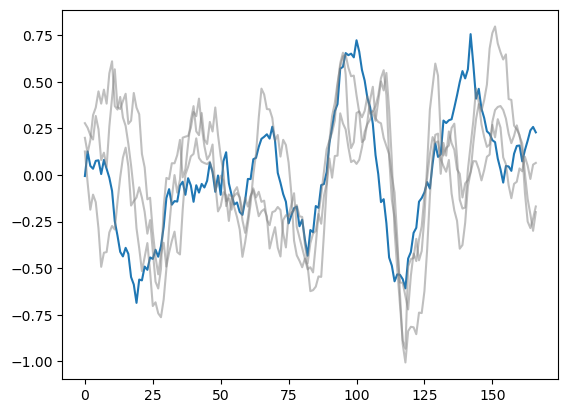

In [19]:
plt.plot(running_mean(remove_monthly_climatology_fast(CERES['Ng'], 3)) )
plt.plot(running_mean(remove_monthly_climatology_fast(N_ds['Ng'][0], 3)),alpha=0.5,color='gray' )
plt.plot(running_mean(remove_monthly_climatology_fast(N_ds['Ng'][1], 3)),alpha=0.5,color='gray' )
plt.plot(running_mean(remove_monthly_climatology_fast(N_ds['Ng'][2], 3)),alpha=0.5,color='gray' )

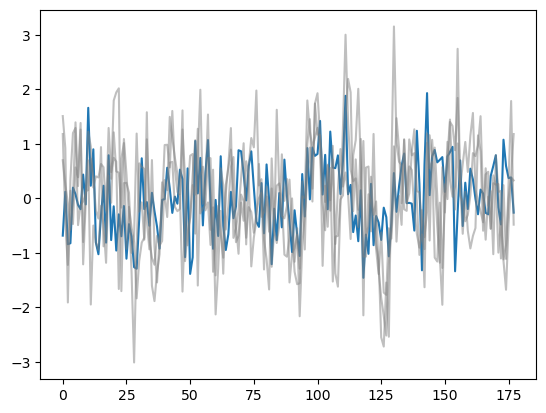

In [20]:
plt.plot(remove_monthly_climatology_fast(CERES['Ng'], 3) )
plt.plot(remove_monthly_climatology_fast(N_ds['Ng'][0], 3),alpha=0.5,color='gray' )
plt.plot(remove_monthly_climatology_fast(N_ds['Ng'][1], 3),alpha=0.5,color='gray' )
plt.plot(remove_monthly_climatology_fast(N_ds['Ng'][2], 3),alpha=0.5,color='gray' )

In [21]:
tas_era5    = detrend_monthly_fast(np.array(ERA5['tas'].data).reshape(len(ERA5.time),-1))

In [23]:
tas_land_era5   = detrend_monthly_fast(np.array(ERA5['tas'].data).reshape(len(ERA5.time),-1)[:,land_idx])

In [ ]:
plot_map(tas_land_era5)

In [22]:
tas_era5.shape

(178, 10368)

In [45]:
def my_EOF(A, weights, n_modes=None):
    A_wtd = (A - A.mean(axis=0))*np.sqrt(weights)
    U, s, Vt = np.linalg.svd(A_wtd, full_matrices=False)
    k = len(s) if n_modes is None else n_modes
    L = s[:k]**2/A.shape[0]
    E = Vt[:k].T
    PC = U[:, :k]*s[:k]
    PC_std = (PC - PC.mean(axis=0))/PC.std(axis=0)
    A_centered = A - A.mean(axis=0)
    EOF_reg = ((PC_std.T@A_centered)/np.sum(PC_std**2, axis=0)[:, None]).T
    return L, E, PC, PC_std, EOF_reg

L, E, PC, PC_std, EOF_reg = my_EOF(tas_era5/np.std(tas_era5,axis=0),weights_1D)
# L, E, PC, PC_std, EOF_reg = my_EOF(tas_era5,weights_1D)
print(L.shape)
print(E.shape)
print(PC.shape)

(178,)
(10368, 178)
(178, 178)


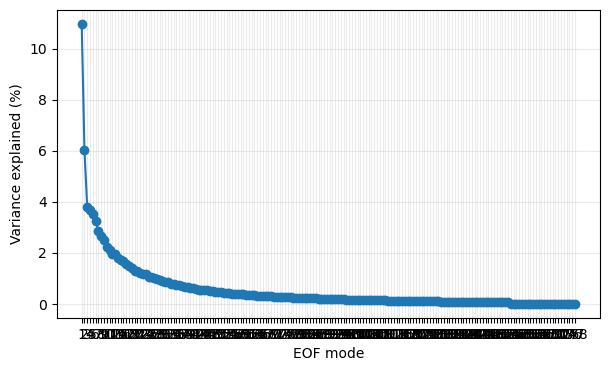

In [46]:
variance_explained = 100*L/L.sum()

plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(L) + 1), variance_explained, "o-")
plt.xlabel("EOF mode")
plt.ylabel("Variance explained (%)")
plt.xticks(np.arange(1, len(L) + 1))
plt.grid(alpha=0.25)
plt.show()

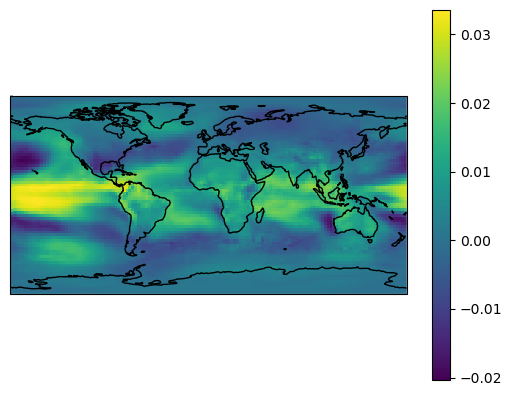

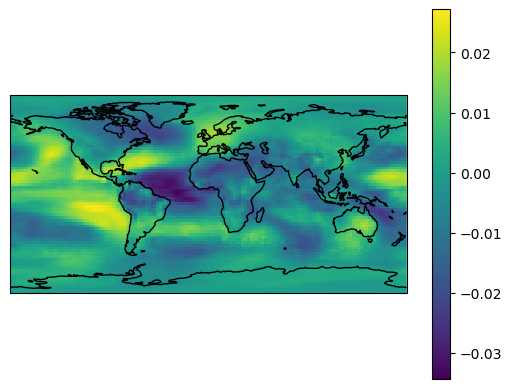

(<Figure size 640x480 with 2 Axes>, <GeoAxes: >)

In [48]:
plot_map(lat,lon,E[:,0].reshape((len(lat),len(lon))))
plot_map(lat,lon,E[:,1].reshape((len(lat),len(lon))))
# plot_map(lat,lon,E[:,2].reshape((len(lat),len(lon))))
# plot_map(lat,lon,E[:,3].reshape((len(lat),len(lon))))


In [ ]:
## Cell 1: AMIP-hist, calculate the netTOA, tas, land tas, sea tas, and EOF1 / EOF2

import xarray as xr
from pathlib import Path

N_anom_amip_hist    = {}
T_anom_amip_hist    = {}

regTiRi_amip_hist   = {}



data_root = Path(
    "/scratch/leiff/MCA/amip_clean/data"
)

for m,model in enumerate(amip_hist_models):
    path_N = (
        data_root
        / "AMIP"
        / model
        / (
            f"N_Amon_{model}_amip-hist_combined_"
            "187001-201412_g025.nc"
        )
    )
    path_T = (
        data_root
        / "AMIP"
        / model
        / (
            f"tas_Amon_{model}_amip-hist_combined_"
            "187001-201412_g025.nc"
        )
    )

    member_covRTi   = []
    member_covTRi   = []
    member_regTiRi  = []

    ## Need to open and process with members in mind
    T_ds        = xc.open_dataset(path_T).sel(time=slice('2000-03','2014-12'))
    N_ds        = xc.open_dataset(path_N).sel(time=slice('2000-03','2014-12'))

    T_ds['T']   = np.sum(T_ds['tas']*ERA5['weights'],axis=(2,3))/np.sum(ERA5['weights'])
    N_ds['Ng']  = np.sum(N_ds['N']*ERA5['weights'],axis=(2,3))/np.sum(ERA5['weights'])

    # display(T_ds)
    # display(N_ds)


    for e in np.arange(amip_hist_n_ensembles[m]):
        print(model)
        print(e)


        # Move spatial and global N and tas into detrended anomalies
        tas_here = detrend_monthly_fast(np.array(T_ds['tas'].data)[e])
        N_here   = detrend_monthly_fast(np.array(N_ds['N'].data)[e])

        tas_here_reshaped    = tas_here.reshape(n_time,n_flat)
        N_here_reshaped      = N_here.reshape(n_time,n_flat)

        T_here   = detrend_monthly_fast(np.array(T_ds['T'].data)[e])
        Ng_here  = detrend_monthly_fast(np.array(N_ds['Ng'].data)[e])

        # print(tas_here_reshaped.shape)
        # print(Ng_here.shape)
        # kill
        
        covRTi_here             = MCA_dave(tas_here_reshaped, Ng_here, weights_1D, standardized=True).reshape(n_lat,n_lon)
        covTRi_here             = MCA_dave(N_here_reshaped, T_here, weights_1D, standardized=True).reshape(n_lat,n_lon)
        _,_,regTiRi_here,_      = lag_linregress_3D(tas_here,N_here)
        
        member_covRTi.append(covRTi_here)
        member_covTRi.append(covTRi_here)
        member_regTiRi.append(regTiRi_here)

    # Shape: (number_of_members, lat, lon)
    covRTi_amip_hist[model] = np.stack(
        member_covRTi,
        axis=0,
    )

    covTRi_amip_hist[model] = np.stack(
        member_covTRi,
        axis=0,
    )

    regTiRi_amip_hist[model] = np.stack(
        member_regTiRi,
        axis=0,
    )



In [ ]:

'''
import xarray as xr
from pathlib import Path

covRTi_amip_hist   = {}
covTRi_amip_hist   = {}
regTiRi_amip_hist  = {}



data_root = Path(
    "/scratch/leiff/MCA/amip_clean/data"
)

for m,model in enumerate(amip_hist_models):
    path_N = (
        data_root
        / "AMIP"
        / model
        / (
            f"N_Amon_{model}_amip-hist_combined_"
            "187001-201412_g025.nc"
        )
    )
    path_T = (
        data_root
        / "AMIP"
        / model
        / (
            f"tas_Amon_{model}_amip-hist_combined_"
            "187001-201412_g025.nc"
        )
    )

    member_covRTi   = []
    member_covTRi   = []
    member_regTiRi  = []

    ## Need to open and process with members in mind
    T_ds        = xc.open_dataset(path_T).sel(time=slice('2000-03','2014-12'))
    N_ds        = xc.open_dataset(path_N).sel(time=slice('2000-03','2014-12'))

    T_ds['T']   = np.sum(T_ds['tas']*ERA5['weights'],axis=(2,3))/np.sum(ERA5['weights'])
    N_ds['Ng']  = np.sum(N_ds['N']*ERA5['weights'],axis=(2,3))/np.sum(ERA5['weights'])

    # display(T_ds)
    # display(N_ds)


    for e in np.arange(amip_hist_n_ensembles[m]):
        print(model)
        print(e)


        # Move spatial and global N and tas into detrended anomalies
        tas_here = detrend_monthly_fast(np.array(T_ds['tas'].data)[e])
        N_here   = detrend_monthly_fast(np.array(N_ds['N'].data)[e])

        tas_here_reshaped    = tas_here.reshape(n_time,n_flat)
        N_here_reshaped      = N_here.reshape(n_time,n_flat)

        T_here   = detrend_monthly_fast(np.array(T_ds['T'].data)[e])
        Ng_here  = detrend_monthly_fast(np.array(N_ds['Ng'].data)[e])

        # print(tas_here_reshaped.shape)
        # print(Ng_here.shape)
        # kill
        
        covRTi_here             = MCA_dave(tas_here_reshaped, Ng_here, weights_1D, standardized=True).reshape(n_lat,n_lon)
        covTRi_here             = MCA_dave(N_here_reshaped, T_here, weights_1D, standardized=True).reshape(n_lat,n_lon)
        _,_,regTiRi_here,_      = lag_linregress_3D(tas_here,N_here)
        
        member_covRTi.append(covRTi_here)
        member_covTRi.append(covTRi_here)
        member_regTiRi.append(regTiRi_here)

    # Shape: (number_of_members, lat, lon)
    covRTi_amip_hist[model] = np.stack(
        member_covRTi,
        axis=0,
    )

    covTRi_amip_hist[model] = np.stack(
        member_covTRi,
        axis=0,
    )

    regTiRi_amip_hist[model] = np.stack(
        member_regTiRi,
        axis=0,
    )
  ''' 